In [2]:
import shutil
import os

# Define the path that was causing the error
cache_dir = '/root/Downloads/ONE'

# Check if it exists and delete it
if os.path.exists(cache_dir):
    try:
        shutil.rmtree(cache_dir)
        print(f"SUCCESS: Deleted {cache_dir}. You have freed up disk space.")
    except OSError as e:
        print(f"ERROR: Could not delete folder. Reason: {e}")
else:
    print(f"NOTE: The folder {cache_dir} does not exist. It might already be gone.")

NOTE: The folder /root/Downloads/ONE does not exist. It might already be gone.


In [3]:
!du -sh /root/Downloads/ONE/*

du: cannot access '/root/Downloads/ONE/*': No such file or directory


In [2]:
# =============================================================================
# PART 1: ROBUST SETUP BLOCK (Your specific configuration)
# =============================================================================
!pip install --quiet ONE-api
!pip install --quiet ibllib

import pandas as pd
import numpy as np
from collections import defaultdict
import os
import sys
import warnings

# Brainbox & IBL imports
from brainbox.io.one import SpikeSortingLoader
from iblatlas.atlas import AllenAtlas
from one.api import ONE
from one.remote.aws import s3_download_file, get_s3_public

# 1. Threading Configuration (Critical for Jupyter stability)
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

# 2. Initialize ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

# 3. Suppress warnings
warnings.simplefilter("ignore", FutureWarning)

# 4. S3 & Path Handling (Version Compatible)
python_ver = sys.version_info
if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    """
    Robust function to load aggregate data tables directly from S3.
    """
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

# Initialize Atlas (globally available for the functions below)
ba = AllenAtlas()

# =============================================================================
# PART 2: GENERALISABLE TOOL FUNCTIONS
# =============================================================================

def get_behavioral_metrics(session_id):
    """
    Calculates behavioral metrics relevant to the 'Confidence' project.
    Returns a dictionary of metrics.
    """
    try:
        # Load only the necessary columns to save bandwidth
        trials = one.load_object(session_id, 'trials',
                                 attribute=['feedbackType', 'choice', 'contrastLeft', 'contrastRight', 'response_times', 'stimOn_times'])

        # --- Standard Metric: Lapse Rate ---
        # Easy trials: contrast > 50%
        is_easy = (trials['contrastLeft'] > 0.5) | (trials['contrastRight'] > 0.5)
        # Lapse: Incorrect (feedback -1) on easy trials
        lapse_count = np.sum((trials['feedbackType'] == -1) & (trials['choice'] != 0) & is_easy)
        no_lapse_count = np.sum((trials['feedbackType'] == 1) & (trials['choice'] != 0) & is_easy)

        # --- New Project Metric: Confidence / Reaction Time ---
        # Reaction time is a proxy for confidence (faster = more confident)
        reaction_times = trials['response_times'] - trials['stimOn_times']
        median_rt = np.nanmedian(reaction_times)

        return {
            'Lapse Trials': lapse_count,
            'No Lapse Trials': no_lapse_count,
            'Median Reaction Time': median_rt,
            'Total Trials': len(trials['choice'])
        }
    except Exception as e:
        # print(f"Warning: Could not load trials for {session_id}: {e}") # Optional: Uncomment to debug
        return {'Lapse Trials': np.nan, 'No Lapse Trials': np.nan, 'Median Reaction Time': np.nan, 'Total Trials': 0}

def get_neural_metrics(pid, region_target):
    """
    Calculates neural yield for a specific probe insertion in a target region.
    """
    try:
        ssl = SpikeSortingLoader(one=one, pid=pid, atlas=ba)
        # Load acronym/label directly
        spikes, clusters, channels = ssl.load_spike_sorting(dataset_types=['clusters.acronym', 'clusters.label'])
        clusters = ssl.merge_clusters(spikes, clusters, channels)

        # Filter for "good" clusters in the target region
        is_good = clusters['label'] == 1
        is_in_region = clusters['acronym'] == region_target

        count = np.sum(is_good & is_in_region)
        return count
    except Exception as e:
        # print(f"Warning: Neural load failed for PID {pid}: {e}") # Optional: Uncomment to debug
        return 0

def generate_eid_metadata(regions=None, eids=None):
    """
    The Master Lookup Tool.
    Args:
        regions (list): List of brain region acronyms (e.g., ['VTa', 'LH', 'CA1'])
        eids (list): List of specific Session IDs (if you already have them)
    """
    results = []

    # Mode 1: Search by Region (Discovery)
    if regions:
        print(f"🔎 Searching for sessions containing: {regions}...")
        for reg in regions:
            insertions = one.search_insertions(atlas_acronym=reg, details=True)
            if not insertions or not insertions[0]:
                print(f"  x No insertions found for {reg}")
                continue

            pids, details = insertions
            for pid, det in zip(pids, details):
                sess_id = det['session']
                subject = det['session_info']['subject']

                # Perform Calculations
                beh_metrics = get_behavioral_metrics(sess_id)
                neural_count = get_neural_metrics(pid, reg)

                # Only keep sessions with data (Neural OR Behavior)
                if neural_count > 0 or beh_metrics['Total Trials'] > 0:
                    row = {
                        'Region': reg,
                        'Subject': subject,
                        'EID': sess_id,
                        'Probe ID': pid,
                        'Good Clusters (ROI)': neural_count
                    }
                    row.update(beh_metrics) # Add lapse/RT data
                    results.append(row)
                    print(f"  ✓ Found {subject} | {reg} | Clusters: {neural_count} | RT: {beh_metrics.get('Median Reaction Time'):.3f}s")

    # Mode 2: Look up by EID (Metadata Retrieval)
    elif eids:
        print(f"🔎 Extracting metadata for {len(eids)} specific EIDs...")
        for eid in eids:
            try:
                det = one.get_details(eid)
                subj = det['subject'] if det else "Unknown"

                beh_metrics = get_behavioral_metrics(eid)

                row = {
                    'Region': 'Global/All',
                    'Subject': subj,
                    'EID': eid,
                    'Probe ID': 'N/A',
                    'Good Clusters (ROI)': 'N/A'
                }
                row.update(beh_metrics)
                results.append(row)
            except Exception as e:
                print(f"Error retrieving EID {eid}: {e}")

    return pd.DataFrame(results)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.8/413.8 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 9.4 MB/s eta 0:00

100%|██████████| 31.470260620117188/31.470260620117188 [00:01<00:00, 16.00it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:00<00:00,  4.00it/s]


In [3]:
# Convert the atlas regions to a DataFrame for easy viewing
df_regions = pd.DataFrame({
    'id': ba.regions.id,
    'acronym': ba.regions.acronym,
    'name': ba.regions.name
})

# Display the first few rows
print(df_regions.head())

    id acronym                           name
0    0    void                           void
1  997    root                           root
2    8    grey  Basic cell groups and regions
3  567      CH                       Cerebrum
4  688     CTX                Cerebral cortex


Processing session c557324b-b95d-414c-888f-6ee1329a2329...


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_025/2020-08-12/001/alf/probe01/pykilosort/#2024-05-06#/spikes.amps.npy: 100%|██████████| 436M/436M [00:09<00:00, 47.6MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_025/2020-08-12/001/alf/probe01/pykilosort/#2024-05-06#/spikes.clusters.npy: 100%|██████████| 218M/218M [00:02<00:00, 86.1MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_025/2020-08-12/001/alf/probe01/pykilosort/#2024-05-06#/spikes.depths.npy: 100%|██████████| 436M/436M [00:08<00:00, 53.6MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_025/2020-08-12/001/alf/probe01/pykilosort/#2024-05-06#/spikes.times.npy: 100%|██████████| 436M/436M [00:04<00:00, 91.5MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_025/2020-08-12/001/alf/probe01/pykilosort/#2024-05-06#/clusters.channel

  -> Using all regions. Found 207 neurons.
  -> Aligning 207 neurons over 1053 trials...
  -> Running T-tests...
  ★ Best Neuron ID: 369 (MB)
  ★ Significance: p=2.0280e-54


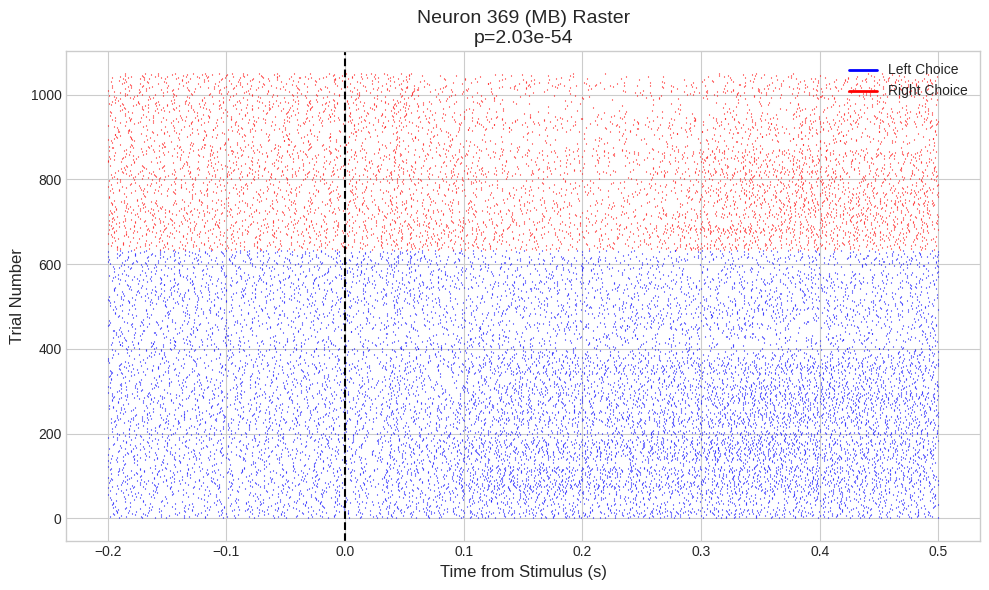

  -> Training Decoder...
  ★ Population Decoding Accuracy: 90.15%


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from brainbox.io.one import SpikeSortingLoader
from one.api import ONE
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Authenticate with the IBL database
one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True)

def analyze_decision_neuron(eid, brain_region=None, pre_time=0.2, post_time=0.5, bin_size=0.025, one=one):
    """
    Analyzes a specific session to identify, visualize, and decode from the
    most decision-selective neuron.

    Args:
        eid (str): Session UUID
        brain_region (str, optional): Atlas acronym to filter neurons (e.g., 'VISp').
                                      If None, analyzes all regions.
    """
    print(f"Processing session {eid}...")

    try:
        # --- LOAD DATA ---
        sl = SpikeSortingLoader(eid=eid, one=one)
        spikes, clusters, channels = sl.load_spike_sorting()
        clusters = sl.merge_clusters(spikes, clusters, channels)
        trials = one.load_object(eid, 'trials', collection='alf')

        # --- FILTER NEURONS ---
        clusters_df = pd.DataFrame(clusters)

        # Base filter: Good label
        is_good = clusters_df['label'] == 1

        # Optional filter: Brain Region
        if brain_region:
            is_in_region = clusters_df['acronym'] == brain_region
            good_clusters = clusters_df[is_good & is_in_region]
            print(f"  -> Filtering for region '{brain_region}'. Found {len(good_clusters)} neurons.")
        else:
            good_clusters = clusters_df[is_good]
            print(f"  -> Using all regions. Found {len(good_clusters)} neurons.")

        if good_clusters.empty:
            print(f"  ❌ No good clusters found. Skipping.")
            return

        # --- ALIGNMENT (MANUAL BINNING) ---
        # Filter valid trials
        valid_mask = ~np.isnan(trials.choice) & ~np.isnan(trials.stimOn_times)
        choice = trials.choice[valid_mask]
        stim_on = trials.stimOn_times[valid_mask]

        n_trials = len(choice)
        n_neurons = len(good_clusters)

        # Matrix X: [n_trials, n_neurons] (Average firing rate in window)
        # We use a single large window for the T-test (0 to post_time)
        X = np.zeros((n_trials, n_neurons))

        print(f"  -> Aligning {n_neurons} neurons over {n_trials} trials...")

        for i, cluster_id in enumerate(good_clusters.index.values):
            # Get timestamps for this neuron
            i_spikes = spikes.times[spikes.clusters == cluster_id]

            # Simple count in the decision window (stim_on to stim_on + post_time)
            # Using searchsorted for speed (faster than histogram for single bin)
            t_start = stim_on
            t_end = stim_on + post_time

            idx_start = np.searchsorted(i_spikes, t_start)
            idx_end = np.searchsorted(i_spikes, t_end)

            # Calculate Rate (spikes / duration)
            X[:, i] = (idx_end - idx_start) / post_time

        # --- IDENTIFY BEST NEURON ---
        print("  -> Running T-tests...")
        y = choice
        X_left = X[y == -1]
        X_right = X[y == 1]
        p_values = []

        for n in range(n_neurons):
            # Check if neuron fired at all
            if np.sum(X[:, n]) > 0:
                t_stat, p = ttest_ind(X_left[:, n], X_right[:, n], equal_var=False)
                p_values.append(p)
            else:
                p_values.append(1.0) # Ignore silent neurons

        best_idx_local = np.argmin(p_values)
        best_cluster_id = good_clusters.index.values[best_idx_local]
        best_p_value = np.min(p_values)
        best_region = good_clusters.iloc[best_idx_local]['acronym']

        print(f"  ★ Best Neuron ID: {best_cluster_id} ({best_region})")
        print(f"  ★ Significance: p={best_p_value:.4e}")

        # --- VISUALIZATION (RASTER) ---
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(10, 6))

        best_neuron_spikes = spikes.times[spikes.clusters == best_cluster_id]
        trials_left = stim_on[y == -1]
        trials_right = stim_on[y == 1]

        # Helper to plot raster rows
        def plot_raster_rows(events, spike_times, color, row_offset):
            for j, t in enumerate(events):
                # Window: -pre_time to +post_time
                t_min = t - pre_time
                t_max = t + post_time
                trial_spikes = spike_times[(spike_times >= t_min) & (spike_times <= t_max)]

                # Align to 0
                aligned_spikes = trial_spikes - t
                ax.vlines(aligned_spikes, row_offset + j, row_offset + j + 1, color=color, lw=0.8)
            return row_offset + len(events)

        # Plot Left (Blue) then Right (Red)
        current_row = 0
        current_row = plot_raster_rows(trials_left, best_neuron_spikes, 'blue', current_row)
        plot_raster_rows(trials_right, best_neuron_spikes, 'red', current_row)

        ax.axvline(0, color='k', linestyle='--', label='Stimulus Onset')
        ax.set_title(f'Neuron {best_cluster_id} ({best_region}) Raster\np={best_p_value:.2e}', fontsize=14)
        ax.set_xlabel('Time from Stimulus (s)', fontsize=12)
        ax.set_ylabel('Trial Number', fontsize=12)

        # Custom Legend
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='blue', lw=2),
                        Line2D([0], [0], color='red', lw=2)]
        ax.legend(custom_lines, ['Left Choice', 'Right Choice'], loc='upper right')

        plt.tight_layout()
        plt.show()

        # --- DECODING ---
        print("  -> Training Decoder...")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        print(f"  ★ Population Decoding Accuracy: {acc*100:.2f}%")

    except Exception as e:
        print(f"❌ Error processing session {eid}: {e}")
        import traceback
        traceback.print_exc()

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

# 1. Define your target session
target_eid = 'c557324b-b95d-414c-888f-6ee1329a2329'

# 2. Run the analysis
# You can specify a region (e.g., 'VISp') or leave it None to search the whole probe
analyze_decision_neuron(target_eid, brain_region=None)

In [4]:
# =============================================================================
# PART 3: USAGE EXAMPLE
# =============================================================================

# Define the regions you are interested in (e.g., Hippocampus CA1 and Visual Cortex)
target_regions = ['CA1', 'VISp']

# Run the tool
df_results = generate_eid_metadata(regions=target_regions)

# Display the final table
print("\n--- Metadata Lookup Results ---")
display(df_results)

🔎 Searching for sessions containing: ['CA1', 'VISp']...


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/spikes.amps.npy: 100%|██████████| 647M/647M [00:08<00:00, 79.9MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/spikes.clusters.npy: 100%|██████████| 323M/323M [00:04<00:00, 71.6MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/spikes.depths.npy: 100%|██████████| 647M/647M [00:08<00:00, 74.7MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/spikes.times.npy: 100%|██████████| 647M/647M [00:08<00:00, 72.3MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#202

  ✓ Found MFD_09 | CA1 | Clusters: 11 | RT: nans


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_08/2023-09-07/001/alf/probe00/pykilosort/#2024-05-06#/spikes.amps.npy: 100%|██████████| 372M/372M [00:05<00:00, 64.7MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_08/2023-09-07/001/alf/probe00/pykilosort/#2024-05-06#/spikes.clusters.npy: 100%|██████████| 186M/186M [00:02<00:00, 69.9MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_08/2023-09-07/001/alf/probe00/pykilosort/#2024-05-06#/spikes.depths.npy: 100%|██████████| 372M/372M [00:04<00:00, 88.8MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_08/2023-09-07/001/alf/probe00/pykilosort/#2024-05-06#/spikes.times.npy: 100%|██████████| 372M/372M [00:04<00:00, 83.9MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_08/2023-09-07/001/alf/probe00/pykilosort/#202

  ✓ Found MFD_08 | CA1 | Clusters: 11 | RT: nans


...

  ✓ Found FMR025 | CA1 | Clusters: 1 | RT: nans


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/FMR025/2021-08-31/001/alf/probe00/pykilosort/spikes.depths.npy: 100%|██████████| 18.7M/18.7M [00:02<00:00, 7.04MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/FMR025/2021-08-31/001/alf/probe00/pykilosort/spikes.clusters.npy: 100%|██████████| 9.36M/9.36M [00:01<00:00, 9.06MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/FMR025/2021-08-31/001/alf/probe00/pykilosort/spikes.times.npy: 100%|██████████| 18.7M/18.7M [00:01<00:00, 17.2MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/FMR025/2021-08-31/001/alf/probe00/pykilosort/spikes.amps.npy: 100%|██████████| 18.7M/18.7M [00:01<00:00, 18.2MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/FMR025/2021-08-31/001/alf/probe00/pykilosort/clusters.channels.npy: 100%|██████████| 2.83k/2.83k [00:00<00:00, 6.61kB/s]
(S3) /r

  ✓ Found FMR025 | CA1 | Clusters: 1 | RT: nans


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-02600/2021-08-27/001/alf/probe00/pykilosort/spikes.times.npy: 100%|██████████| 94.4M/94.4M [00:03<00:00, 31.4MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-02600/2021-08-27/001/alf/probe00/pykilosort/spikes.depths.npy: 100%|██████████| 94.4M/94.4M [00:01<00:00, 52.8MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-02600/2021-08-27/001/alf/probe00/pykilosort/spikes.clusters.npy: 100%|██████████| 47.2M/47.2M [00:00<00:00, 48.8MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-02600/2021-08-27/001/alf/probe00/pykilosort/spikes.amps.npy: 100%|██████████| 94.4M/94.4M [00:01<00:00, 55.3MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-02600/2021-08-27/001/alf/probe00/pykilosort/clusters.channels.npy: 100%|██████████| 4.30k/4.30k [00:00<00:00, 9.24kB/s]
(S

KeyboardInterrupt: 